### imports & directories

In [1]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from dataclasses import dataclass, asdict
from pathlib import Path

import analysis.plot as plot
from analysis.locking_map import run_sinusoidal_locking_map

ROOT = Path.cwd().parent
FIG_DIR = ROOT / "fig/phase_locking_search"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "results/phase_locking_search"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

### parameters & helpers

In [2]:
T = 30
TRANSIENT = 1

NEURON_A_PARAMS = dict(
    name = "neuron A",
    V_th = 0.01
)

NEURON_B_PARAMS = dict(
    name = "neuron B"
)

N_WORKERS = max(1, mp.cpu_count() - 1)

In [3]:
@dataclass(frozen=True)
class SynapseConfig:
    """
    frozen data class for different synapse configurations
    """
    w_exc:   float
    tau_exc: float
    w_inh:   float
    tau_inh: float

    @property
    def id(self):
        return (f"wE{self.w_exc:.3f}_tE{self.tau_exc:.3f}_wI{self.w_inh:.3f}_tI{self.tau_inh:.3f}")

def oat_design(ref: SynapseConfig, levels: dict[str, np.ndarray]):
    """
    generate a one-at-a-time (OAT) parameter sweep
        - start from the reference configuration
        - create variants where exactly one parameter is changed to each value specified in `levels`
    """
    configs = {ref}     # include reference configuration
    for name, values in levels.items():
        for v in values:
            # add configuration
            # (for name: round values to avoid duplicate configurations caused by floating-point representation differences)
            configs.add(SynapseConfig(**{**asdict(ref), name: round(float(v), 6)}))     
    return sorted(configs, key=lambda c: c.id)

In [4]:
def search(cfg, I0_values, f_values):
    """
    investigate phase locking for system
    with synapse configuration `config`
    for different sinusoidal input currents
    """

    SYN_EXC_PARAMS = dict(
        w=cfg.w_exc, 
        tau_syn=cfg.tau_exc
    )
    SYN_INH_PARAMS = dict(
        w=cfg.w_inh, 
        tau_syn=cfg.tau_inh
    )
    
    df = run_sinusoidal_locking_map(
        I0_values,
        f_values,
        T,
        TRANSIENT,
        NEURON_A_PARAMS, 
        NEURON_B_PARAMS,
        SYN_EXC_PARAMS, 
        SYN_INH_PARAMS,
        N_WORKERS
    )

    df.to_csv(RESULTS_DIR / f"{cfg.id}.csv", index=False)
    
    return df

# parameter space

In [5]:
# synapse configuration
REFERENCE = SynapseConfig(w_exc=0.1, tau_exc=0.05, w_inh=0.7, tau_inh=0.07)

configs = oat_design(REFERENCE, levels={
    "w_exc":   np.linspace(0.01, 0.09, 9),
    "tau_exc": np.linspace(0.01, 0.09, 9),
    "w_inh":   np.linspace(0.10, 0.90, 9),
    "tau_inh": np.linspace(0.01, 0.09, 9)
})

configs = [cfg for cfg in configs]

# input current
I0_values = np.linspace(0.1, 1.0, 10)   # amplitude
f_values = np.linspace(0.1, 10.0, 20)   # frequency

print(f"synapses               : {len(configs)} configurations")
print(f"input current          : {len(f_values)} freq × {len(I0_values)} I₀")
print(f"number of simulations  : {len(configs) * len(f_values) * len(I0_values)}")

synapses               : 34 configurations
input current          : 20 freq × 10 I₀
number of simulations  : 6800


In [6]:
# save configurations as a Data Frame
configs_df = pd.DataFrame([asdict(c) for c in configs])
configs_df.insert(0, "config_id", [c.id for c in configs])
configs_df.to_csv(RESULTS_DIR / "configs.csv", index=False)
configs_df

,config_id,w_exc,tau_exc,w_inh,tau_inh
0,wE0.010_tE0.050_wI0.700_tI0.070,0.01,0.05,0.7,0.07
1,wE0.020_tE0.050_wI0.700_tI0.070,0.02,0.05,0.7,0.07
2,wE0.030_tE0.050_wI0.700_tI0.070,0.03,0.05,0.7,0.07
3,wE0.040_tE0.050_wI0.700_tI0.070,0.04,0.05,0.7,0.07
4,wE0.050_tE0.050_wI0.700_tI0.070,0.05,0.05,0.7,0.07
5,wE0.060_tE0.050_wI0.700_tI0.070,0.06,0.05,0.7,0.07
6,wE0.070_tE0.050_wI0.700_tI0.070,0.07,0.05,0.7,0.07
7,wE0.080_tE0.050_wI0.700_tI0.070,0.08,0.05,0.7,0.07
8,wE0.090_tE0.050_wI0.700_tI0.070,0.09,0.05,0.7,0.07
9,wE0.100_tE0.010_wI0.700_tI0.070,0.10,0.01,0.7,0.07


# run
WARNING: this code may take long time to run (6800 simulations 30s each)

In [ ]:
n = len(configs)
for i, cfg in enumerate(configs, 1):
    print("\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print(f"[{i}/{n}] {cfg.id}")
    df = search(cfg, I0_values, f_values)
    print("\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

# plot
- 1:1 phase locking between external drive and neuron A

/Users/marta/Documents/education/um/bachelor thesis/qmlif_loop/src/analysis/plot.py:336: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 5))


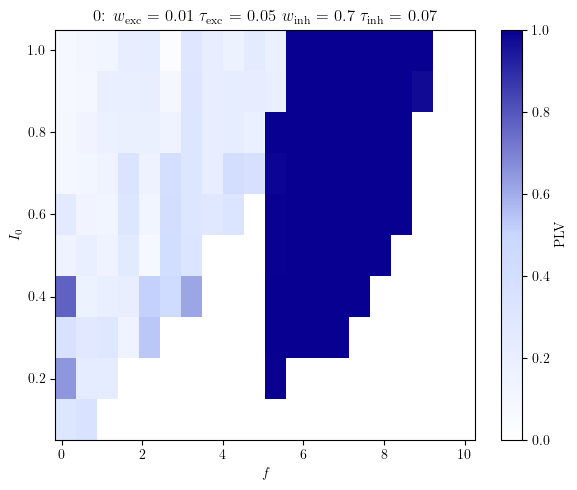

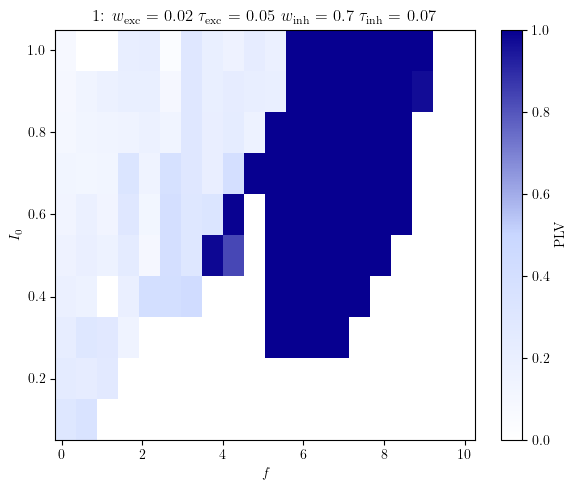

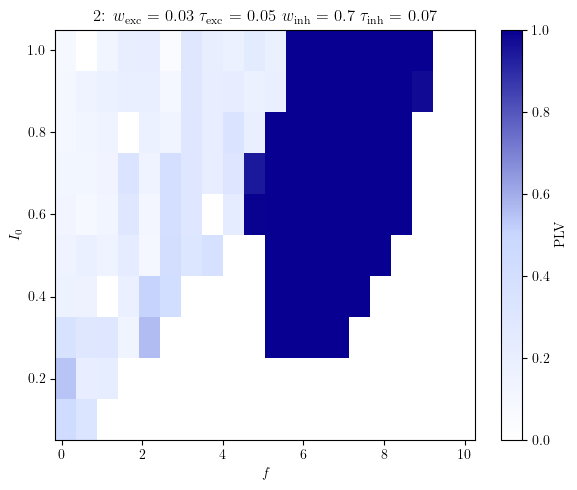

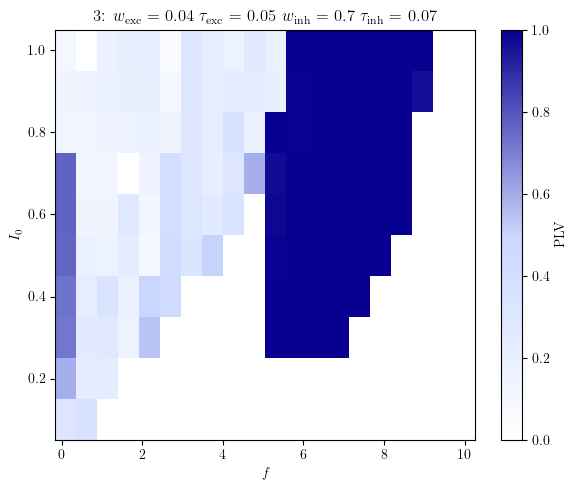

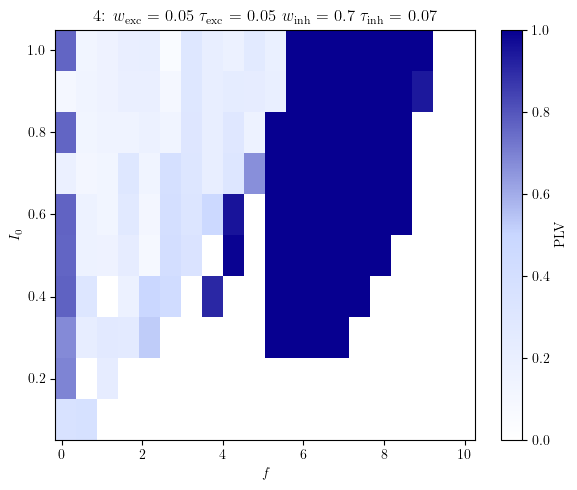

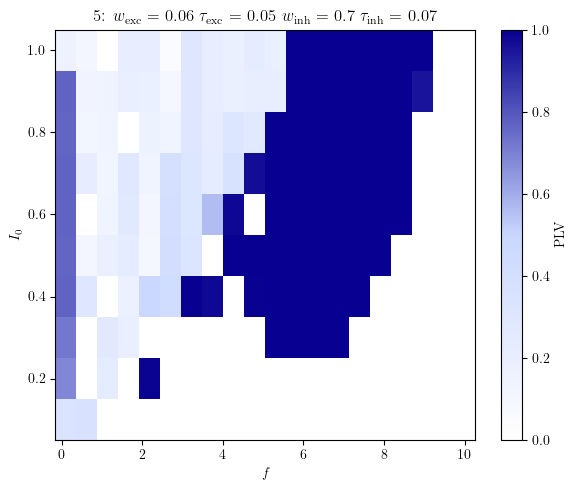

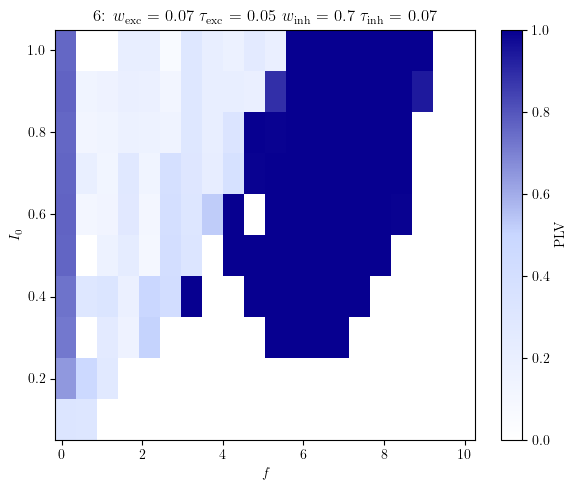

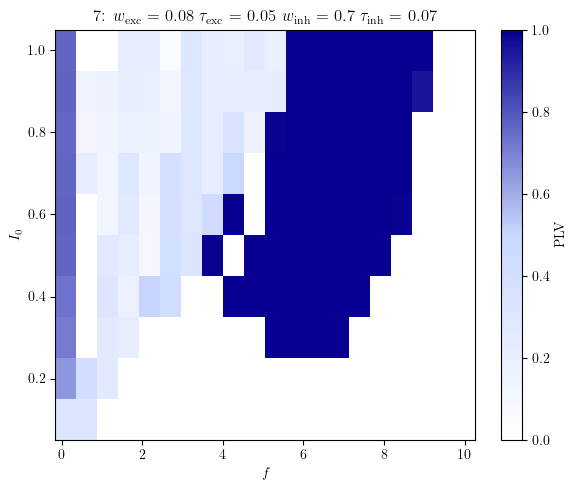

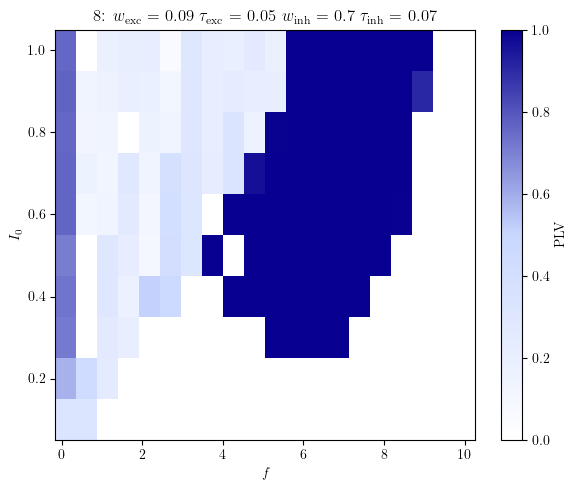

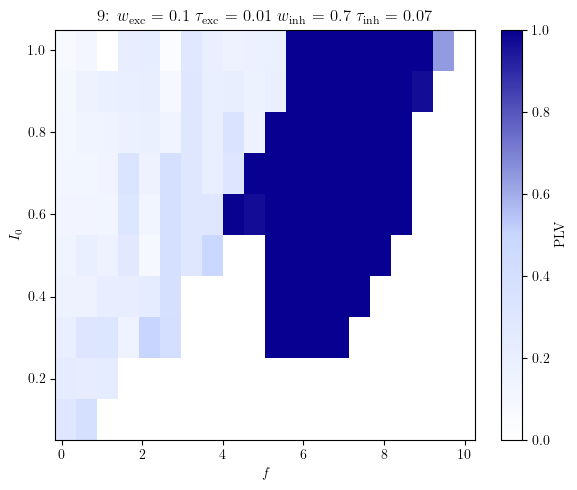

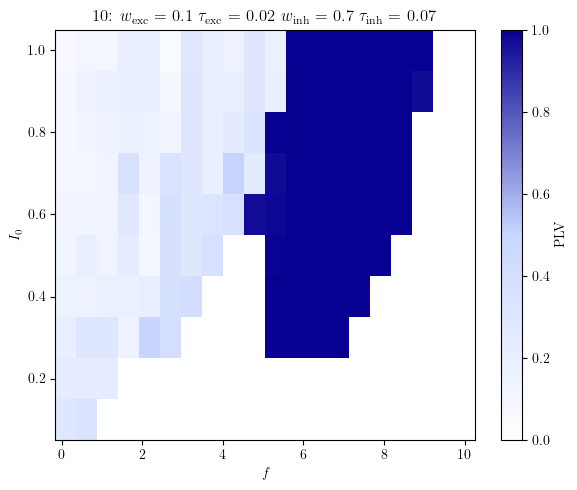

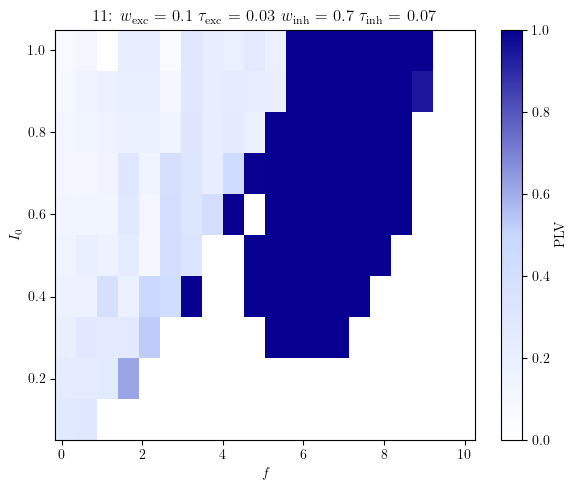

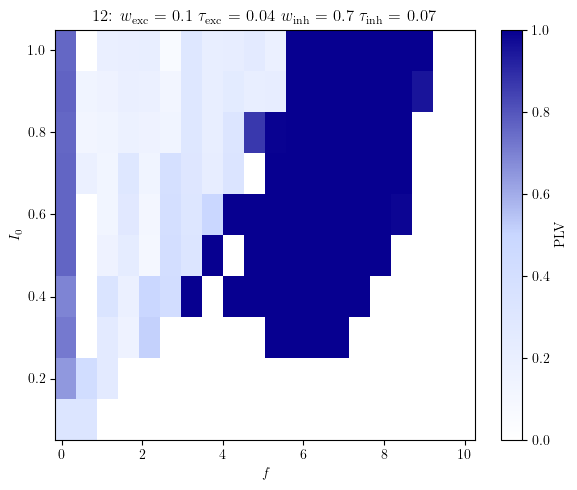

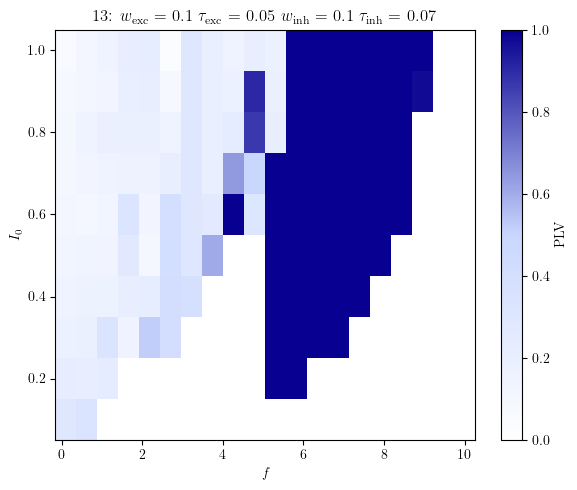

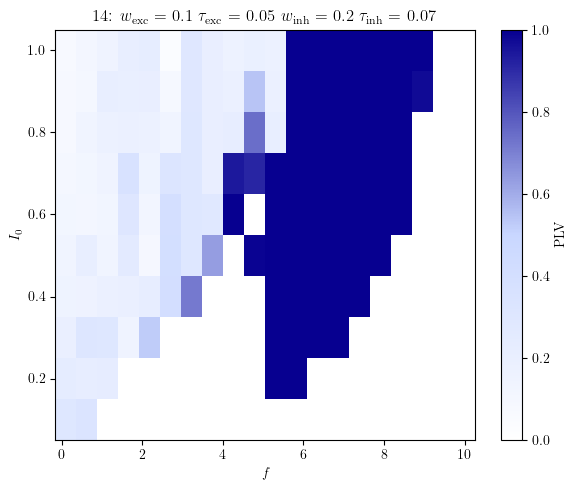

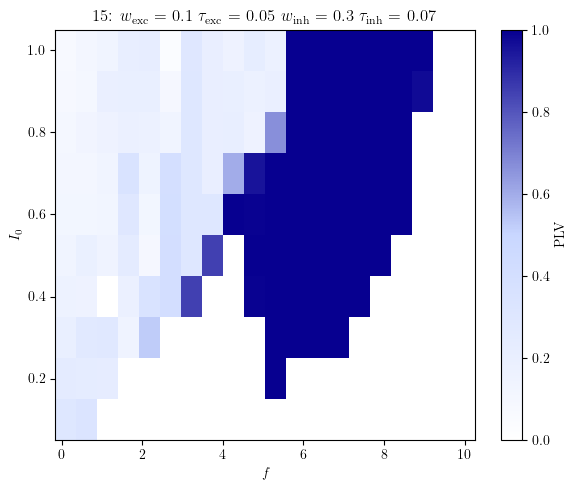

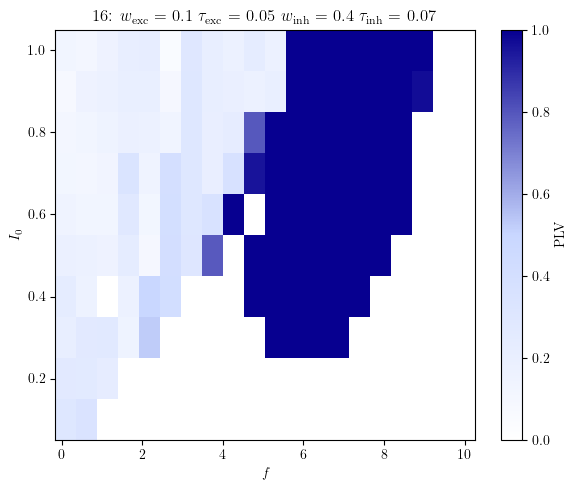

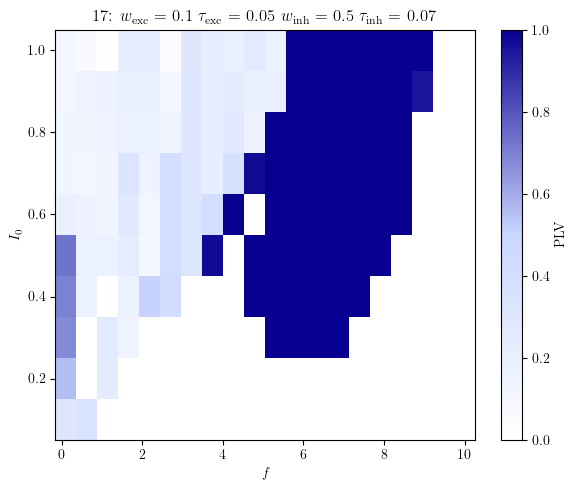

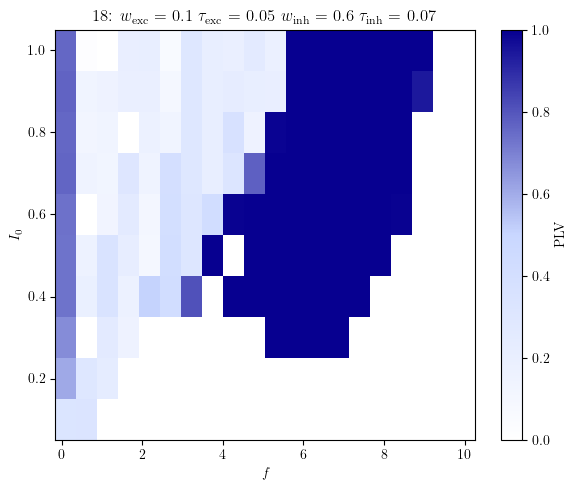

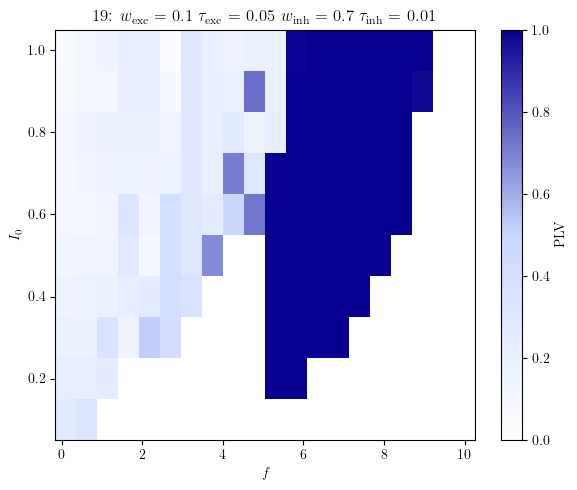

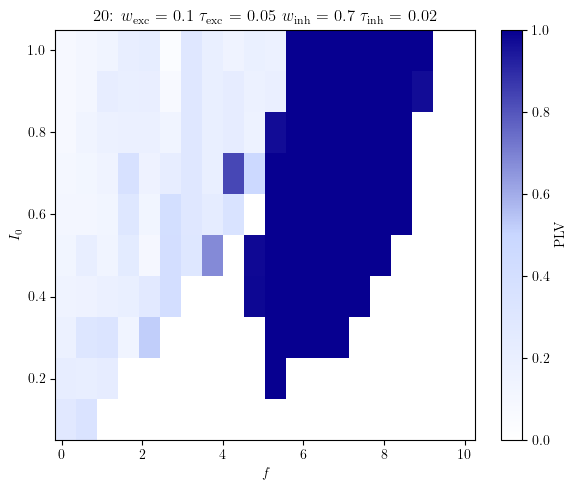

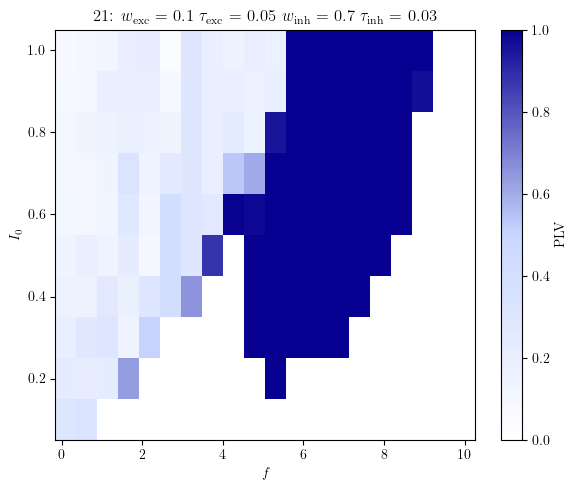

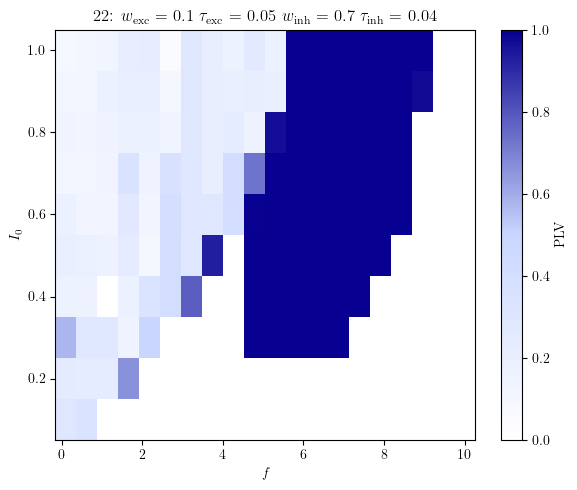

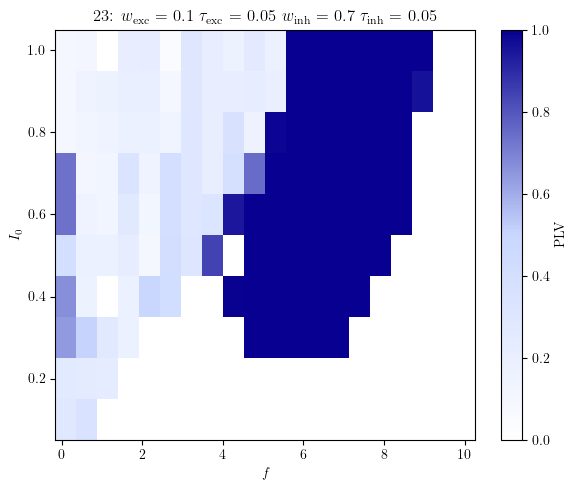

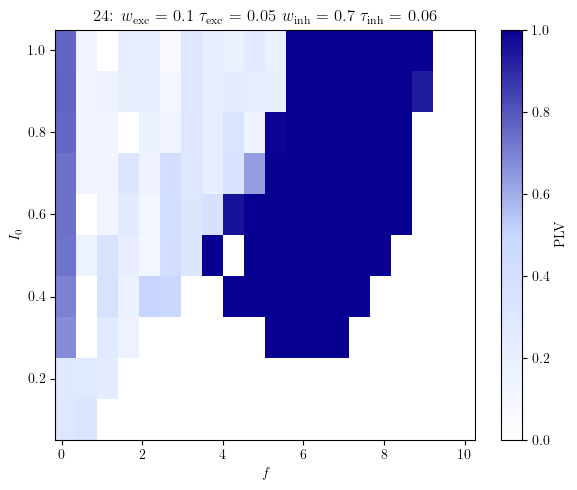

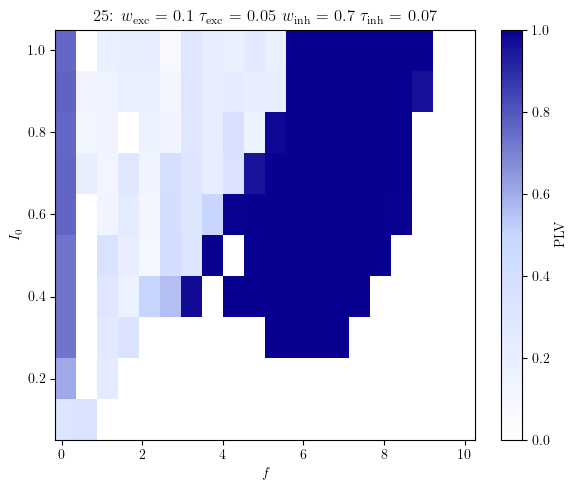

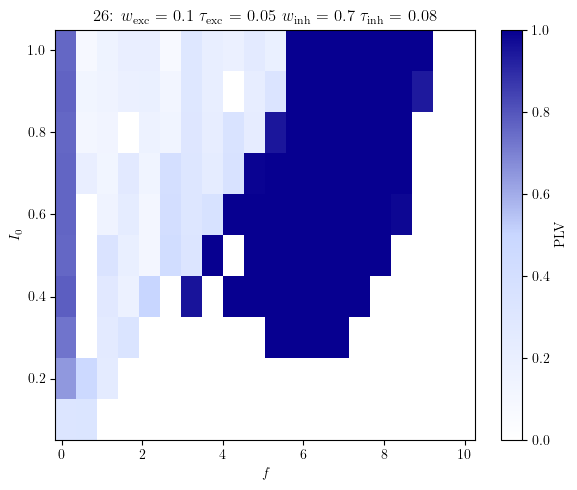

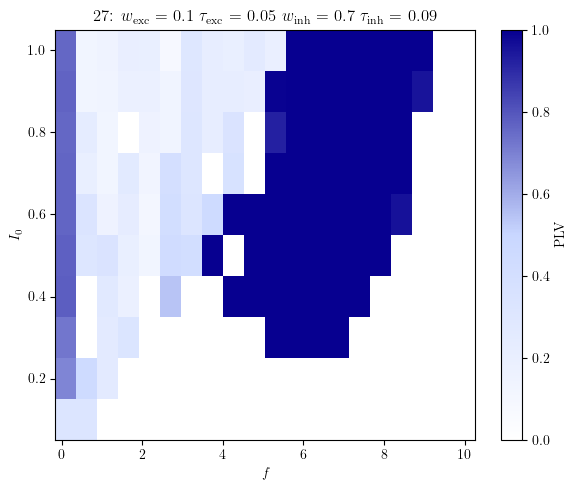

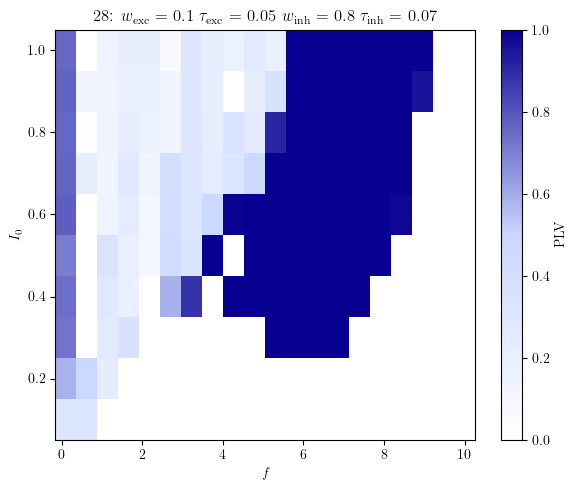

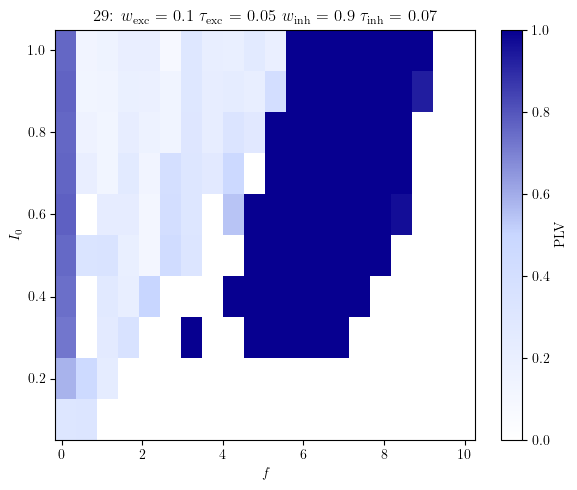

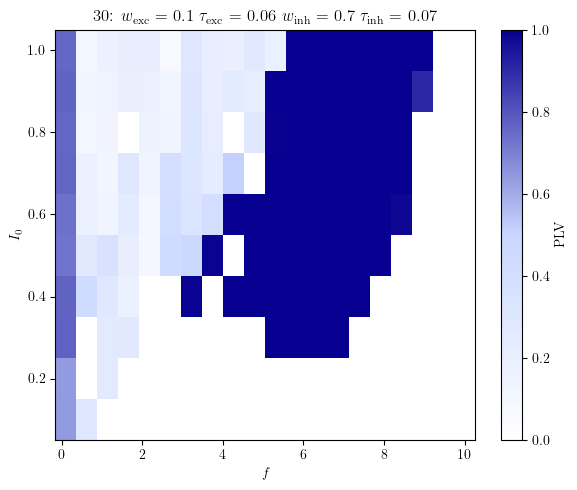

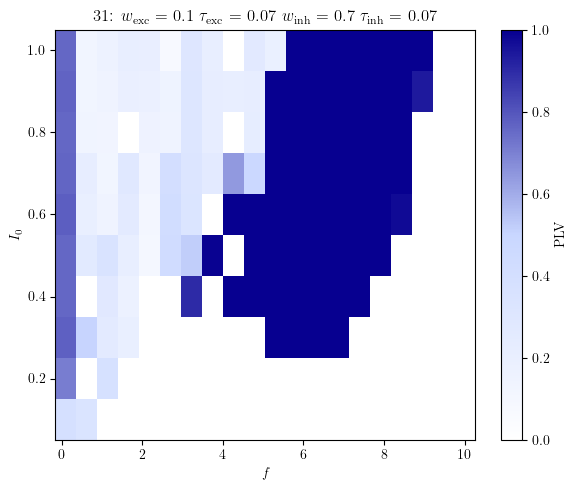

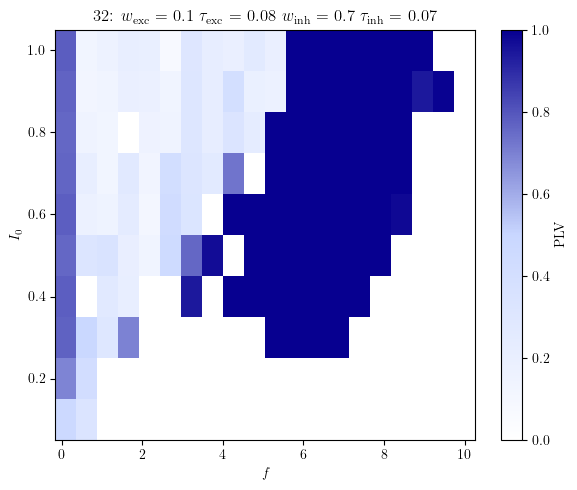

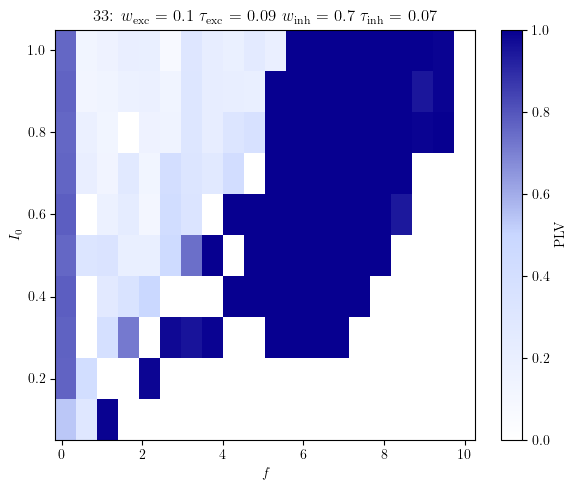

In [7]:
i = 0
for c in (configs):
    df = pd.read_csv(RESULTS_DIR / f"{c.id}.csv")
    title = fr"{i}: $w_\mathrm{{exc}}$ = {c.w_exc} $\tau_\mathrm{{exc}}$ = {c.tau_exc} $w_\mathrm{{inh}}$ = {c.w_inh} $\tau_\mathrm{{inh}}$ = {c.tau_inh}"
    fig = plot.plv_locking_map(df, "plv_11_A", title=title, cbar_label="PLV")
    i += 1

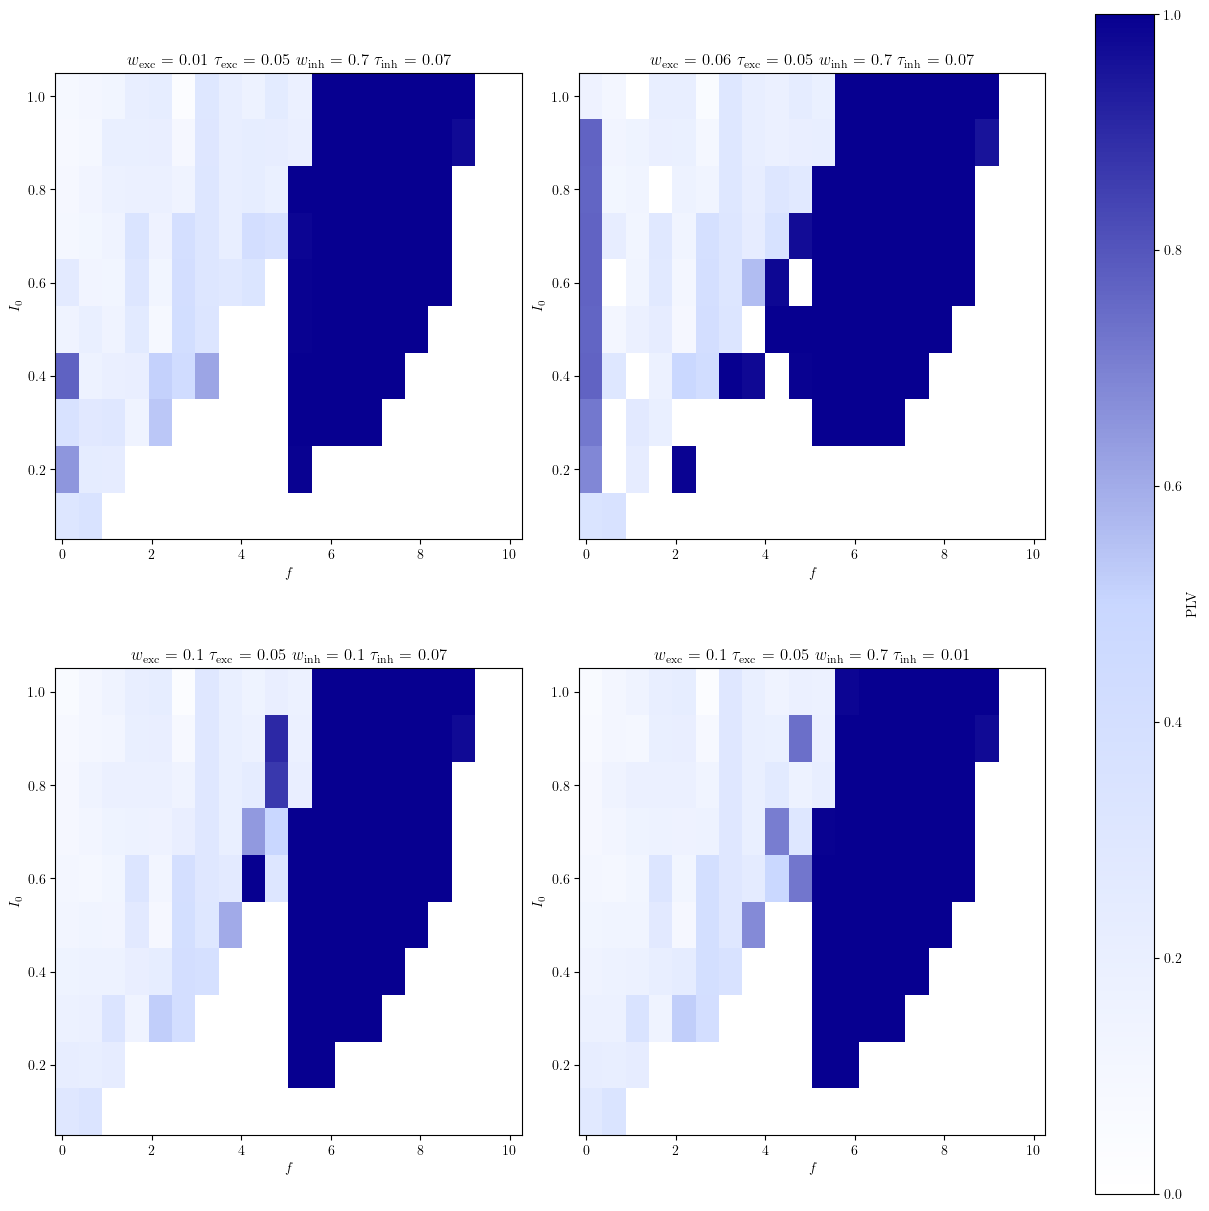

In [8]:
def make_title(c):
    return fr"$w_\mathrm{{exc}}$ = {c.w_exc} $\tau_\mathrm{{exc}}$ = {c.tau_exc} $w_\mathrm{{inh}}$ = {c.w_inh} $\tau_\mathrm{{inh}}$ = {c.tau_inh}"

df1 = pd.read_csv(RESULTS_DIR / f"{configs[0].id}.csv")
df2 = pd.read_csv(RESULTS_DIR / f"{configs[5].id}.csv")
df3 = pd.read_csv(RESULTS_DIR / f"{configs[13].id}.csv")
df4 = pd.read_csv(RESULTS_DIR / f"{configs[19].id}.csv")

fig = plot.plv_locking_map_4(
    df1, df2, df3, df4,
    title1=make_title(configs[0]),
    title2=make_title(configs[5]),
    title3=make_title(configs[13]),
    title4=make_title(configs[19]),
)
fig.savefig(FIG_DIR/"example_lockings.pdf", bbox_inches="tight")